<a href="https://colab.research.google.com/github/EstherSudargo/Banana-Segmentation-using-YOLO26-and-YOLO26-Vmamba/blob/main/YOLO%2BVMamba_banana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Sun Jun 28 13:47:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.9 MB/s eta 0:00:00


In [3]:
%pip install -q "ultralytics>=8.4.0" supervision roboflow

!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)


In [5]:
import yaml
import os
from google.colab import drive

drive.mount('/content/drive')

data_config ={
  'path': '/content/drive/MyDrive/banana_dataset',
  'train': 'train/images',
  'val': 'valid/images',
  'names':{
      0: 'banana'
  }
}

with open('/content/custom_dataset.yaml', 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("SUCCESS: /content/custom_dataset.yaml has been created!")

Mounted at /content/drive
SUCCESS: /content/custom_dataset.yaml has been created!


In [6]:
!yolo task=segment mode=predict model=yolo26m-seg.pt source="/content/drive/MyDrive/banana_dataset/valid/images_rotated_1deg_final/image_6_rot350.jpg" save=True verbose=False

Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m-seg summary (fused): 149 layers, 23,569,148 parameters, 0 gradients, 121.5 GFLOPs
Results saved to /content/runs/segment/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [7]:
!ls -la /content/runs/segment/predict/

total 128
drwxr-xr-x 2 root root   4096 Jun 28 13:49 .
drwxr-xr-x 3 root root   4096 Jun 28 13:49 ..
-rw-r--r-- 1 root root 122667 Jun 28 13:49 image_6_rot350.jpg


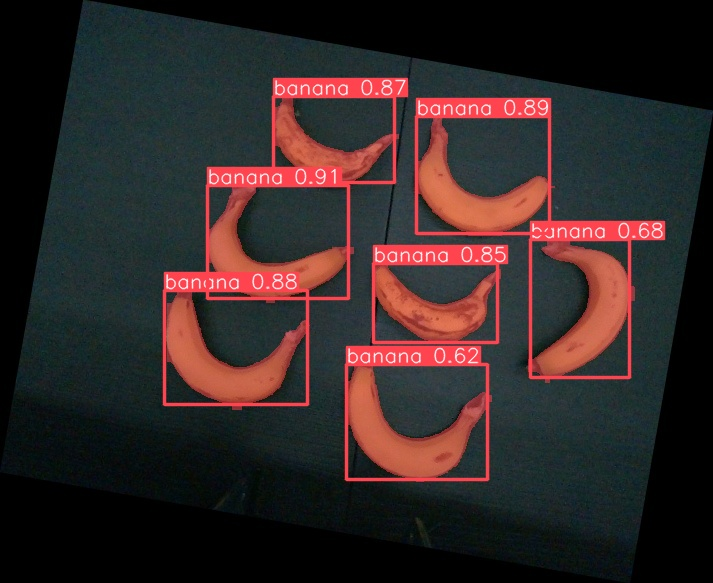

In [8]:
from IPython.display import Image as IPyImage

IPyImage(filename='/content/runs/segment/predict/image_6_rot350.jpg', width=600)

Train Model

In [9]:
!yolo task=segment mode=train model=yolo26m-seg.pt data=/content/custom_dataset.yaml epochs=50 imgsz=640

Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/custom_dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

In [11]:
!yolo task=segment mode=predict model=/content/runs/segment/train/weights/best.pt source="/content/drive/MyDrive/banana_dataset/valid/images/image_6.jpg" save=True conf=0.25

Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m-seg summary (fused): 149 layers, 23,508,239 parameters, 0 gradients, 121.2 GFLOPs

image 1/1 /content/drive/MyDrive/banana_dataset/valid/images/image_6.jpg: 480x640 5 bananas, 135.7ms
Speed: 2.7ms preprocess, 135.7ms inference, 12.2ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/segment/predict-2
💡 Learn more at https://docs.ultralytics.com/modes/predict


Test Model



Running YOLO26 inference on 1 test images...


image 1/1 /content/drive/MyDrive/banana_dataset/valid/images/image_6.jpg: 480x640 5 bananas, 1113.8ms
Speed: 1.7ms preprocess, 1113.8ms inference, 25.1ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/segment/predict-3

Displaying annotated predictions from: runs/segment/predict-3


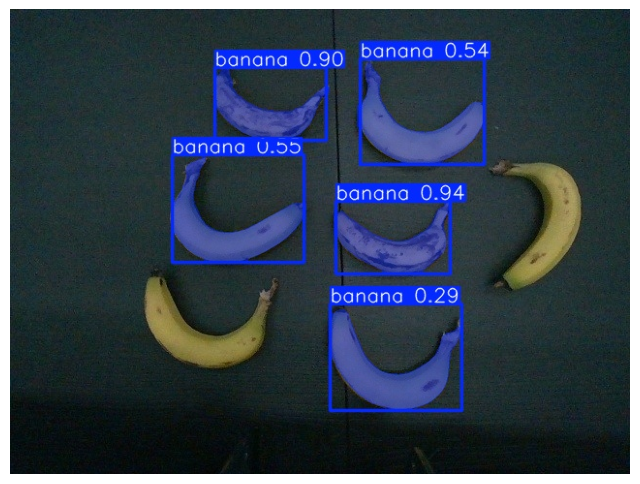

In [12]:

import glob
from PIL import Image
from IPython.display import display
import matplotlib.pyplot as plt
from ultralytics import YOLO

TEST_IMAGES_DIR = os.path.join(data_config['path'], data_config['val'])
test_image_files = glob.glob(os.path.join(TEST_IMAGES_DIR, "*.jpg")) + glob.glob(os.path.join(TEST_IMAGES_DIR, "*.png"))

if len(test_image_files) == 0:
    print(f"\n[WARNING] Zero files found in {TEST_IMAGES_DIR}. Check your images directory.")
else:
    print(f"\nRunning YOLO26 inference on {len(test_image_files)} test images...\n")

    model_path = "/content/runs/segment/train/weights/best.pt"
    model = YOLO(model_path)

    inference_results = model.predict(
        source=TEST_IMAGES_DIR,
        imgsz=640,
        save=True,
        conf=0.25,
        device='cpu'
    )

    predict_dirs = sorted(glob.glob("runs/segment/predict*"))
    if predict_dirs:
        latest_predict_dir = predict_dirs[-1]
        predicted_outputs = glob.glob(f"{latest_predict_dir}/*.jpg") + glob.glob(f"{latest_predict_dir}/*.png")

        print(f"\nDisplaying annotated predictions from: {latest_predict_dir}")
        for img_path in predicted_outputs[:3]:
            img = Image.open(img_path)
            plt.figure(figsize=(8, 8))
            plt.imshow(img)
            plt.axis('off')
            plt.show()
    else:
        print("✗ No saved visualization images found in runs/segment/predict*")

### Model Evaluation

I will now evaluate the trained model on the validation dataset. This will provide metrics such as precision, recall, and mAP.

In [13]:
from ultralytics import YOLO
import pandas as pd

model_path = "/content/runs/segment/train/weights/best.pt"
model = YOLO(model_path)

metrics = model.val(data='/content/custom_dataset.yaml')

import yaml
with open('/content/custom_dataset.yaml', 'r') as f:
    data_config_eval = yaml.safe_load(f)
class_names = data_config_eval['names']

print("\n================ MODEL EVALUATION REPORT ================")

print("\n--- Overall Metrics (Bounding Box Detection) ---")
print(f"mAP50:    {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")

print("\n--- Overall Metrics (Segmentation Mask) ---")
print(f"Mask mAP50:    {metrics.seg.map50:.4f}")
print(f"Mask mAP50-95: {metrics.seg.map:.4f}")

print("\n--- Per-Class Metrics (Bounding Box Detection) ---")
box_metrics_df = pd.DataFrame({
    'Class': [class_names[i] for i in range(len(class_names))],
    'Precision': metrics.box.p.tolist(),
    'Recall': metrics.box.r.tolist()
})
print(box_metrics_df.to_string(index=False))

print("\n--- Per-Class Metrics (Segmentation Mask) ---")
mask_metrics_df = pd.DataFrame({
    'Class': [class_names[i] for i in range(len(class_names))],
    'Precision': metrics.seg.p.tolist(),
    'Recall': metrics.seg.r.tolist()
})
print(mask_metrics_df.to_string(index=False))

print("=========================================================")

Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m-seg summary (fused): 149 layers, 23,508,239 parameters, 0 gradients, 121.2 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.0 ms, read: 22.4±0.0 MB/s, size: 83.1 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/18H3Z0BMkkEo0l2qtAuqHu6dQa8d3vFkC/banana_dataset/valid/labels.cache... 1 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1/1 45.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 5.0it/s 0.2s
                   all          1          7      0.867          1      0.995       0.95      0.867          1      0.995      0.877
Speed: 1.5ms preprocess, 100.4ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to /content/runs/segment/val

================ MODEL EVALUATION REPORT ================

--- Overall Metrics (Bounding Box Detection) ---
mAP50:    0.

WARNING ⚠️ ConfusionMatrix plot failure: ConfusionMatrix.plot() got an unexpected keyword argument 'save'
Bounding Box Confusion Matrix saved to runs/segment/val/confusion_matrix.png


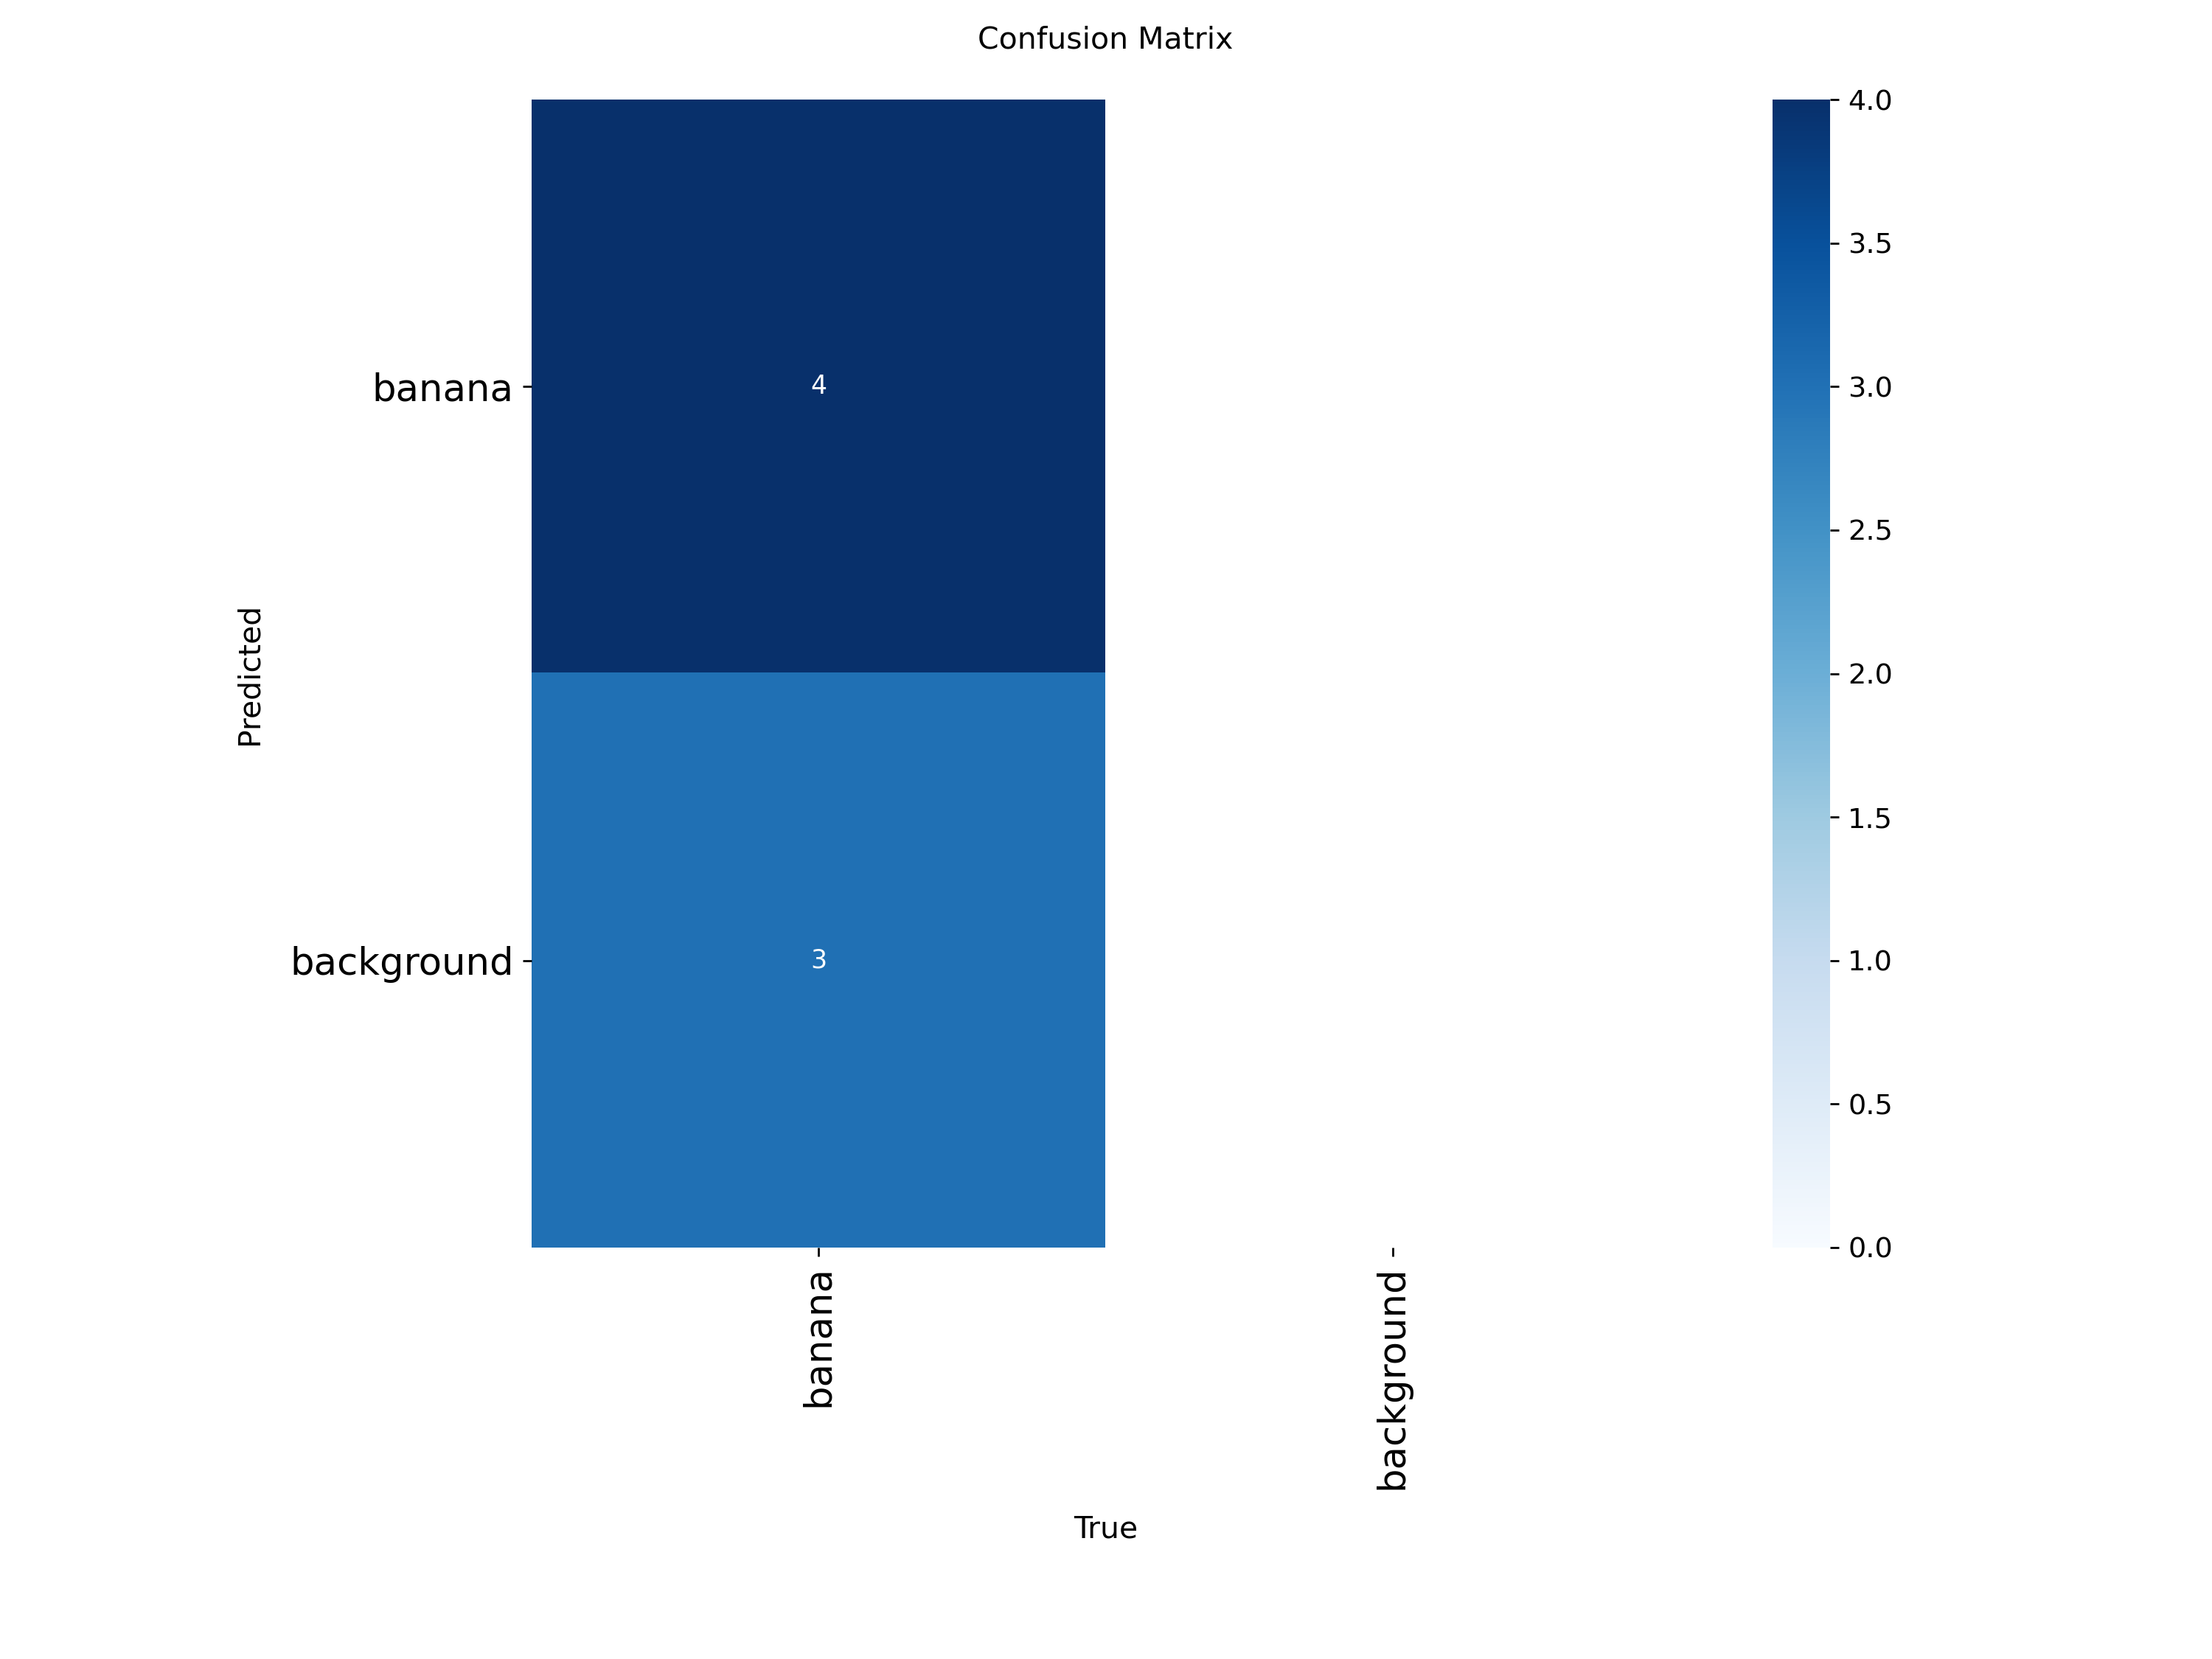

In [14]:

box_confusion_matrix_plot = metrics.confusion_matrix.plot(normalize=False, save=True, names=class_names, cbar=True, cmap='Blues')
print("Bounding Box Confusion Matrix saved to runs/segment/val/confusion_matrix.png")

from IPython.display import Image as IPyImage

display(IPyImage(filename='/content/runs/segment/val/confusion_matrix.png'))


In [15]:
import os

def save_yolo_model_to_both_locations(model, primary_path, backup_path, label_name="final model"):
    """
    Saves a YOLO model to both a permanent and temporary path.
    """
    os.makedirs(os.path.dirname(primary_path), exist_ok=True)
    os.makedirs(os.path.dirname(backup_path), exist_ok=True)

    try:
        model.save(primary_path)
        print(f" Successfully saved [{label_name}] to permanent path: {primary_path}")
    except Exception as e:
        print(f"Failed saving to primary path: {e}")

    try:
        model.save(backup_path)
        print(f" Successfully saved [{label_name}] to temporary path: {backup_path}")
    except Exception as e:
        print(f"Failed saving to backup path: {e}")


In [ ]:
primary_save_path = "/content/drive/MyDrive/yolo_models/yolo26m_seg_best.pt"
backup_save_path = "/content/yolo_temp_saves/yolo26m_seg_best.pt"

save_yolo_model_to_both_locations(model, primary_save_path, backup_save_path, label_name="YOLO26m-seg Trained Model")

 Successfully saved [YOLO26m-seg Trained Model] to permanent path: /content/drive/MyDrive/yolo_models/yolo26m_seg_best.pt
 Successfully saved [YOLO26m-seg Trained Model] to temporary path: /content/yolo_temp_saves/yolo26m_seg_best.pt


In [16]:
from ultralytics import YOLO

yolo26_model_path = "/content/runs/segment/train/weights/best.pt"

yolo26_loaded_model = YOLO(yolo26_model_path)

print(f"YOLO26 model loaded successfully from: {yolo26_model_path}")

YOLO26 model loaded successfully from: /content/runs/segment/train/weights/best.pt


VMamba

In [3]:
%cd /content
!rm -rf ultralytics

!git clone https://github.com/ultralytics/ultralytics.git

%cd /content/ultralytics

!pip install -e .
!pip install timm einops

/content
Cloning into 'ultralytics'...
remote: Enumerating objects: 111259, done.
remote: Counting objects: 100% (1300/1300), done.
remote: Compressing objects: 100% (656/656), done.
remote: Total 111259 (delta 1017), reused 648 (delta 644), pack-reused 109959 (from 4)
Receiving objects: 100% (111259/111259), 59.21 MiB | 17.04 MiB/s, done.
Resolving deltas: 100% (83579/83579), done.
/content/ultralytics
Obtaining file:///content/ultralytics
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ultralytics (pyproject.toml) ... done
  Created wheel for ultralytics: filename=ultralytics-8.4.81-0.editable-py3-none-any.whl size=23353 sha256=cef82b7a7ee4c0fcf4c6d8a8a9eb6067d7c31a561b12a6c56044739ac2799315
  Stored in directory: /tmp/pip-ephem-wheel-cache-pyo4ahtj/wheels/60/e0/59/e2f034f296abbdca5c21e3f5be76b9ca685f13

In [1]:
import yaml
import os
from google.colab import drive

drive.mount('/content/drive')

data_config ={
  'path': '/content/drive/MyDrive/banana_dataset',
  'train': 'train/images',
  'val': 'valid/images',
  'names':{
      0: 'banana'
  }
}

with open('/content/custom_dataset.yaml', 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("SUCCESS: /content/custom_dataset.yaml has been created!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SUCCESS: /content/custom_dataset.yaml has been created!


In [4]:
%%writefile ultralytics/nn/modules/vmamba.py

import torch
import torch.nn as nn

from ultralytics.nn.modules.block import C3k2


class VMambaBlock(nn.Module):

    def __init__(self, channels):

        super().__init__()

        self.norm = nn.BatchNorm2d(channels)

        self.dwconv = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            padding=1,
            groups=channels
        )

        self.pwconv = nn.Conv2d(
            channels,
            channels,
            kernel_size=1
        )

        self.act = nn.SiLU()

    def forward(self, x):

        residual = x

        x = self.norm(x)

        x = self.dwconv(x)

        x = self.pwconv(x)

        x = self.act(x)

        return x + residual


class C3k2VMamba(nn.Module):

    def __init__(
        self,
        c1,
        c2,
        n=1,
        shortcut=False,
        e=0.5
    ):
        super().__init__()

        self.c3 = C3k2(
            c1,
            c2,
            n=n,
            shortcut=shortcut,
            e=e
        )

        self.vmamba = VMambaBlock(c2)

    def forward(self, x):

        x = self.c3(x)

        x = self.vmamba(x)

        return x

Writing ultralytics/nn/modules/vmamba.py


In [5]:
import pathlib

init_file = pathlib.Path(
    "ultralytics/nn/modules/__init__.py"
)

text = init_file.read_text()

if "C3k2VMamba" not in text:
    text += "\nfrom .vmamba import C3k2VMamba\n"

init_file.write_text(text)

print("registered")

registered


In [6]:
import pathlib

file = pathlib.Path(
    "ultralytics/nn/tasks.py"
)

text = file.read_text()

text = text.replace(
    "C3k2,",
    "C3k2,\n        C3k2VMamba,"
)

file.write_text(text)

print("patched")

patched


In [7]:
%%writefile yolo26m-seg-vmamba.yaml

nc: 1

scales:
  n: [0.50, 0.25, 1024]
  s: [0.50, 0.50, 1024]
  m: [0.50, 1.00, 512]
  l: [1.00, 1.00, 512]
  x: [1.00, 1.50, 512]

backbone:

  - [-1, 1, Conv, [64, 3, 2]]
  - [-1, 1, Conv, [128, 3, 2]]

  - [-1, 2, C3k2, [256, False, 0.25]]

  - [-1, 1, Conv, [256, 3, 2]]

  - [-1, 2, C3k2VMamba, [512, False, 0.25]]

  - [-1, 1, Conv, [512, 3, 2]]

  - [-1, 2, C3k2VMamba, [512, True]]

  - [-1, 1, Conv, [1024, 3, 2]]

  - [-1, 2, C3k2VMamba, [1024, True]]

  - [-1, 1, SPPF, [1024, 5, 3, True]]

  - [-1, 2, C2PSA, [1024]]

head:

  - [-1, 1, nn.Upsample, [None, 2, nearest]]
  - [[-1, 6], 1, Concat, [1]]
  - [-1, 2, C3k2, [512, True]]

  - [-1, 1, nn.Upsample, [None, 2, nearest]]
  - [[-1, 4], 1, Concat, [1]]
  - [-1, 2, C3k2, [256, True]]

  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 13], 1, Concat, [1]]
  - [-1, 2, C3k2, [512, True]]

  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 10], 1, Concat, [1]]
  - [-1, 1, C3k2, [1024, True, 0.5, True]]

  - [[16, 19, 22], 1, Segment26, [nc, 32, 256]]

Writing yolo26m-seg-vmamba.yaml


In [18]:
!rm -f /content/drive/MyDrive/banana_dataset/train/*.cache
!rm -f /content/drive/MyDrive/banana_dataset/valid/*.cache

In [19]:
import sys
sys.path.insert(0, "/content/ultralytics")
from ultralytics import YOLO


model = YOLO("/content/ultralytics/yolo26m-seg-vmamba.yaml")

model.load("yolo26m-seg.pt")

model.train(
    data="/content/custom_dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    task="segment"
)

Transferred 566/680 items from pretrained weights
Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/custom_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/ultralytics/yolo26m-seg-vmamba.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, 

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79e5230d5880>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

In [20]:

def save_yolo_model_to_both_locations(model_instance, primary_path, backup_path, label_name="model"):
    os.makedirs(os.path.dirname(primary_path), exist_ok=True)
    os.makedirs(os.path.dirname(backup_path), exist_ok=True)

    try:
        model_instance.save(primary_path)
        print(f" Successfully saved [{label_name}] to permanent path: {primary_path}")
    except Exception as e:
        print(f"Failed saving to primary path: {e}")

    try:
        model_instance.save(backup_path)
        print(f" Successfully saved [{label_name}] to temporary path: {backup_path}")
    except Exception as e:
        print(f"Failed saving to backup path: {e}")


trained_vmamba_path = "/content/ultralytics/runs/segment/train-2/weights/best.pt"
vmamba_model = YOLO(trained_vmamba_path)

gdrive_save_path = "/content/drive/MyDrive/yolo_models/yolo26m_vmamba_seg_best.pt"
local_backup_path = "/content/yolo_temp_saves/yolo26m_vmamba_seg_best.pt"

save_yolo_model_to_both_locations(
    model_instance=vmamba_model,
    primary_path=gdrive_save_path,
    backup_path=local_backup_path,
    label_name="YOLO26m-seg + VMamba Trained Model"
)


 Successfully saved [YOLO26m-seg + VMamba Trained Model] to permanent path: /content/drive/MyDrive/yolo_models/yolo26m_vmamba_seg_best.pt
 Successfully saved [YOLO26m-seg + VMamba Trained Model] to temporary path: /content/yolo_temp_saves/yolo26m_vmamba_seg_best.pt


Loading weights from: /content/drive/MyDrive/yolo_models/yolo26m_vmamba_seg_best.pt
Transferred 680/680 items from pretrained weights
Running inference on: /content/drive/MyDrive/banana_dataset/valid/images/image_6.jpg

image 1/1 /content/drive/MyDrive/banana_dataset/valid/images/image_6.jpg: 480x640 (no detections), 44.7ms
Speed: 2.9ms preprocess, 44.7ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/ultralytics/runs/segment/predict-4

Displaying prediction overlay from: runs/segment/predict-4/image_6.jpg


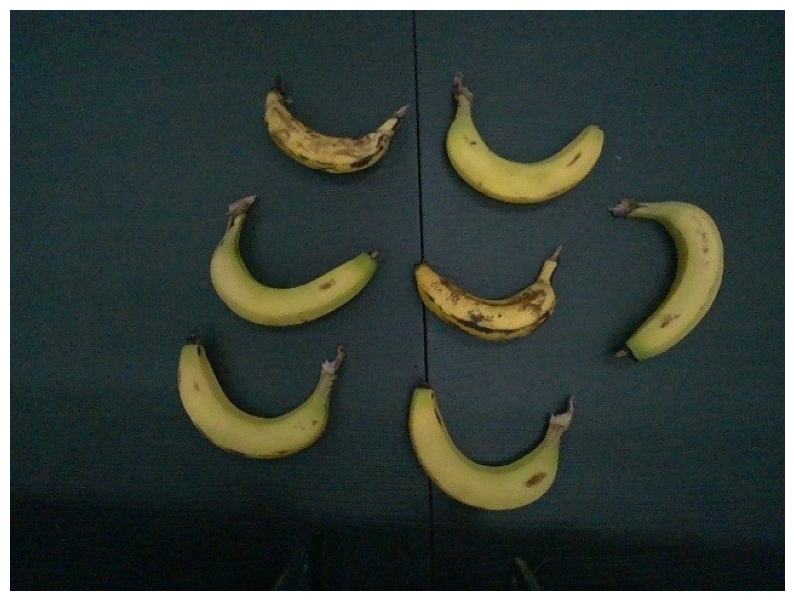

In [21]:
import os
import glob
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

vmamba_cfg_path = "/content/ultralytics/yolo26m-seg-vmamba.yaml"
vmamba_weights_path = "/content/drive/MyDrive/yolo_models/yolo26m_vmamba_seg_best.pt"

if not os.path.exists(vmamba_weights_path):
    vmamba_weights_path = "/content/ultralytics/runs/segment/train-2/weights/best.pt"

print(f"Loading weights from: {vmamba_weights_path}")

model = YOLO(vmamba_cfg_path).load(vmamba_weights_path)

model.model.args['nc'] = 1
model.model.args['names'] = {0: 'banana'}

TEST_IMAGES_DIR = "/content/drive/MyDrive/banana_dataset/valid/images"
test_image_files = glob.glob(os.path.join(TEST_IMAGES_DIR, "*.jpg")) + glob.glob(os.path.join(TEST_IMAGES_DIR, "*.png"))

if len(test_image_files) == 0:
    print(f"\n[WARNING] No images found in {TEST_IMAGES_DIR}.")
else:
    sample_image = test_image_files[0]
    print(f"Running inference on: {sample_image}")

    results = model.predict(
        source=sample_image,
        imgsz=640,
        save=True,
        conf=0.10,
        device=0
    )

    predict_dirs = sorted(glob.glob("/content/ultralytics/runs/segment/predict*") + glob.glob("runs/segment/predict*"))
    if predict_dirs:
        latest_predict_dir = predict_dirs[-1]
        predicted_outputs = glob.glob(f"{latest_predict_dir}/*.jpg") + glob.glob(f"{latest_predict_dir}/*.png")

        if predicted_outputs:
            output_img_path = predicted_outputs[-1]
            print(f"\nDisplaying prediction overlay from: {output_img_path}")
            img = Image.open(output_img_path)
            plt.figure(figsize=(10, 10))
            plt.imshow(img)
            plt.axis('off')
            plt.show()

Evaluating Baseline YOLO26 Model...
Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m-seg summary (fused): 149 layers, 23,508,239 parameters, 0 gradients, 121.2 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.0 ms, read: 31.8±0.0 MB/s, size: 83.1 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/18H3Z0BMkkEo0l2qtAuqHu6dQa8d3vFkC/banana_dataset/valid/labels... 1 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1/1 108.8it/s 0.0s
val: New cache created: /content/drive/.shortcut-targets-by-id/18H3Z0BMkkEo0l2qtAuqHu6dQa8d3vFkC/banana_dataset/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 13.6it/s 0.1s
                   all          1          7      0.867          1      0.995       0.95      0.867          1      0.995      0.877
Speed: 1.5ms preprocess, 52.5ms inference, 0.0ms loss, 4.1ms postprocess per image

Ev

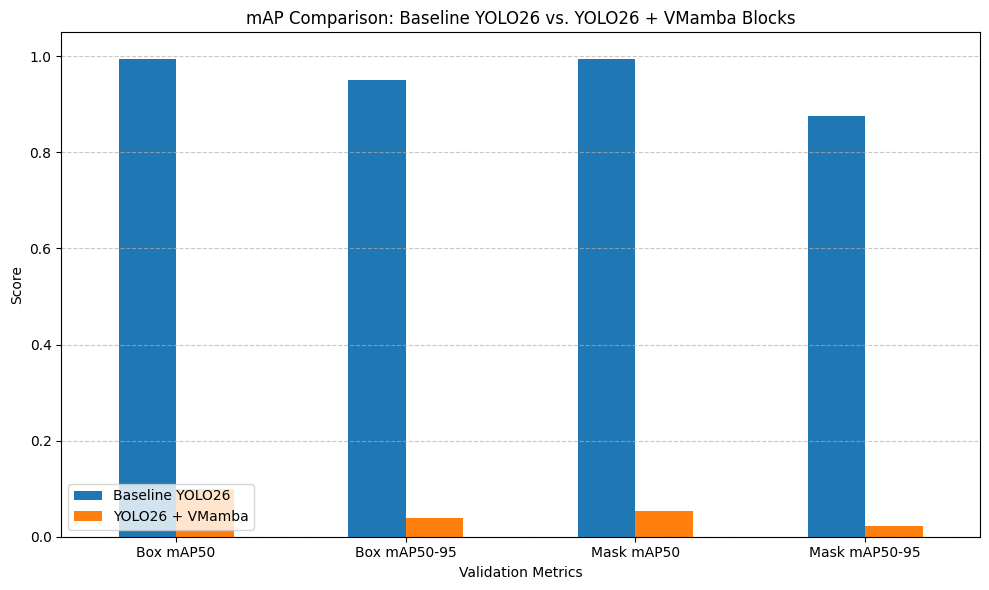

In [22]:
import os
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

baseline_weights = "/content/runs/segment/train/weights/best.pt"
vmamba_weights = "/content/ultralytics/runs/segment/train-2/weights/best.pt"
dataset_yaml = "/content/custom_dataset.yaml"

with open(dataset_yaml, 'r') as f:
    data_config_eval = yaml.safe_load(f)
class_names = list(data_config_eval['names'].values())

print("Evaluating Baseline YOLO26 Model...")
model_base = YOLO(baseline_weights)
metrics_base = model_base.val(data=dataset_yaml, plots=False)

print("\nEvaluating YOLO26 + VMamba Model...")
model_vmamba = YOLO(vmamba_weights)
metrics_vmamba = model_vmamba.val(data=dataset_yaml, plots=False)

summary_data = {
    "Metric": [
        "Box Precision", "Box Recall", "Box mAP50", "Box mAP50-95",
        "Mask Precision", "Mask Recall", "Mask mAP50", "Mask mAP50-95"
    ],
    "Baseline YOLO26": [
        metrics_base.box.mp, metrics_base.box.mr, metrics_base.box.map50, metrics_base.box.map,
        metrics_base.seg.mp, metrics_base.seg.mr, metrics_base.seg.map50, metrics_base.seg.map
    ],
    "YOLO26 + VMamba": [
        metrics_vmamba.box.mp, metrics_vmamba.box.mr, metrics_vmamba.box.map50, metrics_vmamba.box.map,
        metrics_vmamba.seg.mp, metrics_vmamba.seg.mr, metrics_vmamba.seg.map50, metrics_vmamba.seg.map
    ]
}

df_comparison = pd.DataFrame(summary_data)
df_comparison["Delta (%)"] = ((df_comparison["YOLO26 + VMamba"] - df_comparison["Baseline YOLO26"]) / df_comparison["Baseline YOLO26"]) * 100

print("\n=================== OVERALL PERFORMANCE COMPARISON REPORT ===================")
print(df_comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) and abs(x) < 100 else f"{x:.2f}%"))
print("=============================================================================")

df_plot = df_comparison.set_index("Metric")
mAP_metrics = ["Box mAP50", "Box mAP50-95", "Mask mAP50", "Mask mAP50-95"]
df_plot.loc[mAP_metrics, ["Baseline YOLO26", "YOLO26 + VMamba"]].plot(kind="bar", figsize=(10, 6), color=['#1f77b4', '#ff7f0e'])

plt.title("mAP Comparison: Baseline YOLO26 vs. YOLO26 + VMamba Blocks")
plt.ylabel("Score")
plt.xlabel("Validation Metrics")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 1.05)
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig("/content/runs/segment/model_comparison_chart.png")
plt.show()



===================== PER-CLASS MASK MAP BREAKDOWN =====================
 Class  Baseline Mask mAP50-95  VMamba Mask mAP50-95  Improvement
banana                  0.8766                0.0214      -0.8552


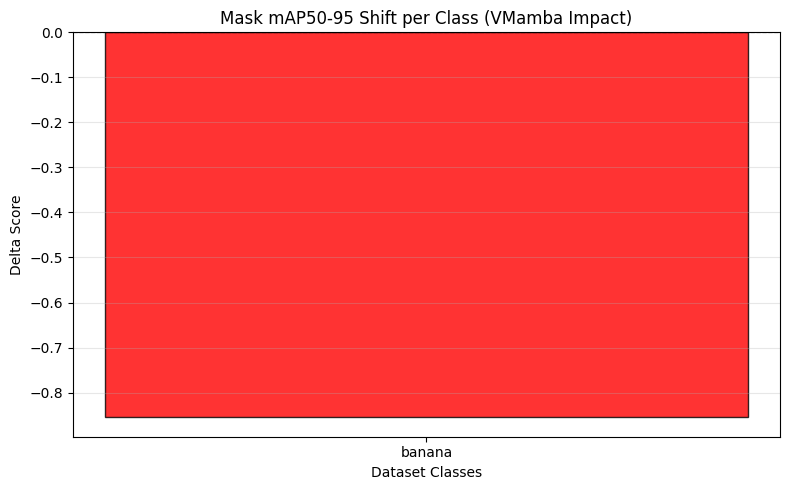

In [23]:
per_class_data = {
    "Class": class_names,
    "Baseline Mask mAP50-95": metrics_base.seg.maps.tolist()[:len(class_names)],
    "VMamba Mask mAP50-95": metrics_vmamba.seg.maps.tolist()[:len(class_names)]
}

df_classes = pd.DataFrame(per_class_data)
df_classes["Improvement"] = df_classes["VMamba Mask mAP50-95"] - df_classes["Baseline Mask mAP50-95"]

print("\n===================== PER-CLASS MASK MAP BREAKDOWN =====================")
print(df_classes.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("========================================================================")

plt.figure(figsize=(8, 5))
colors = ['green' if x >= 0 else 'red' for x in df_classes["Improvement"]]
plt.bar(df_classes["Class"], df_classes["Improvement"], color=colors, edgecolor='black', alpha=0.8)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("Mask mAP50-95 Shift per Class (VMamba Impact)")
plt.ylabel("Delta Score")
plt.xlabel("Dataset Classes")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()